In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv('Nat_Gas.csv')

# Convert Dates column to datetime
df['Dates'] = pd.to_datetime(df['Dates'])

# Sort data by date
df = df.sort_values('Dates')

# Display first rows
print(df.head())

       Dates  Prices
0 2020-10-31    10.1
1 2020-11-30    10.3
2 2020-12-31    11.0
3 2021-01-31    10.9
4 2021-02-28    10.9


C:\Users\hp\AppData\Local\Temp\ipykernel_3576\3984857841.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


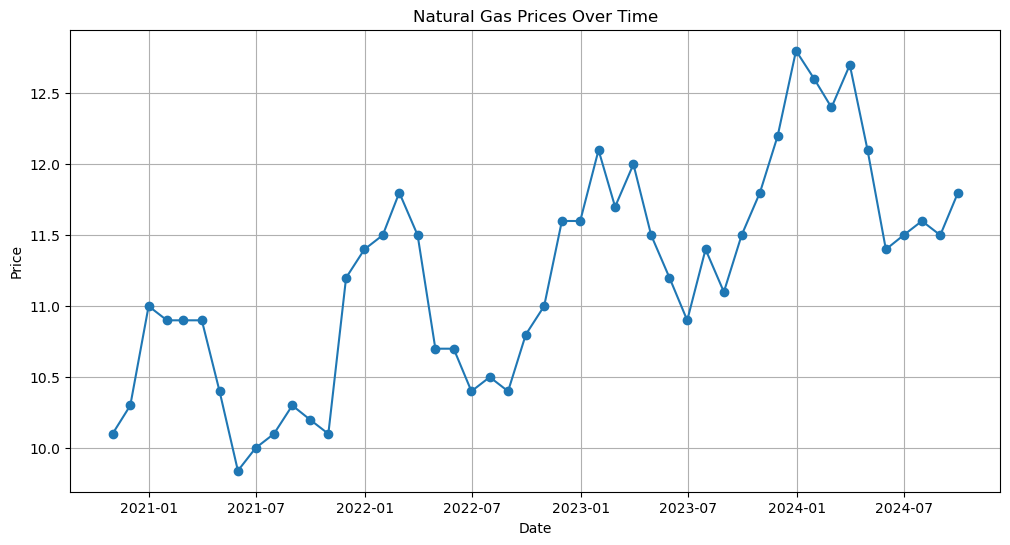

In [20]:
plt.figure(figsize=(12,6))
plt.plot(df['Dates'], df['Prices'], marker='o')
plt.title('Natural Gas Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [21]:
df['Date_Num'] = df['Dates'].map(pd.Timestamp.toordinal)

        Dates  Prices
36 2023-10-31    11.8
37 2023-11-30    12.2
38 2023-12-31    12.8
39 2024-01-31    12.6
40 2024-02-29    12.4
41 2024-03-31    12.7
42 2024-04-30    12.1
43 2024-05-31    11.4
44 2024-06-30    11.5
45 2024-07-31    11.6
46 2024-08-31    11.5
47 2024-09-30    11.8


In [22]:
def get_historical_price(date):

    date = pd.to_datetime(date)
    date_num = date.toordinal()

    price = np.interp(
        date_num,
        df['Date_Num'],
        df['Prices']
    )

    return round(price, 2)

In [23]:
df['Month'] = df['Dates'].dt.month

monthly_avg = df.groupby('Month')['Prices'].mean()

print(monthly_avg)

Month
1     11.775
2     11.700
3     11.775
4     11.175
5     10.785
6     10.700
7     10.900
8     10.825
9     11.075
10    10.750
11    11.325
12    11.700
Name: Prices, dtype: float64


In [24]:
monthly_trend = (
    df['Prices'].iloc[-1]
    - df['Prices'].iloc[0]
) / (len(df)-1)

print("Monthly Trend:", monthly_trend)

Monthly Trend: 0.03617021276595747


In [25]:
last_date = df['Dates'].max()

def get_future_price(date):

    date = pd.to_datetime(date)

    month = date.month

    base_price = monthly_avg[month]

    months_ahead = (
        (date.year - last_date.year) * 12
        + (date.month - last_date.month)
    )

    forecast_price = (
        base_price
        + months_ahead * monthly_trend
    )

    return round(forecast_price, 2)

In [26]:
def get_price(date):

    date = pd.to_datetime(date)

    if date <= last_date:
        return get_historical_price(date)

    else:
        return get_future_price(date)

In [27]:
print(get_price('2023-05-15'))
print(get_price('2024-08-10'))
print(get_price('2025-03-15'))
print(get_price('2025-09-30'))

11.35
11.57
11.99
11.51


In [28]:
future_dates = pd.date_range(
    start='2024-10-31',
    end='2025-09-30',
    freq='M'
)

future_prices = []

for d in future_dates:
    future_prices.append(get_price(d))

C:\Users\hp\AppData\Local\Temp\ipykernel_6464\2978055112.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


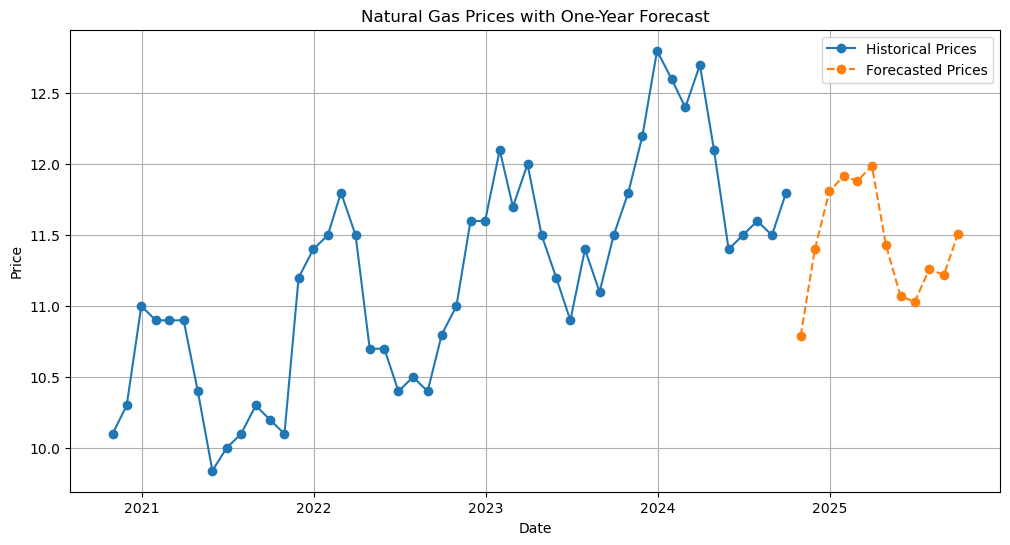

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    df['Dates'],
    df['Prices'],
    marker='o',
    label='Historical Prices'
)

plt.plot(
    future_dates,
    future_prices,
    marker='o',
    linestyle='--',
    label='Forecasted Prices'
)

plt.title('Natural Gas Prices with One-Year Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

The historical natural gas prices exhibit both seasonality and an overall trend. Prices generally increase during winter months due to higher demand and decrease during summer months. To estimate prices for any date, linear interpolation was used for historical dates and a seasonal forecasting approach using monthly averages combined with the overall trend was used for future dates.
